# Zillow dataset

The hierarchy is built bottom-up from Zillow metropolitan sales-count series. Metropolitan areas define the base level. Missing monthly values are filled with zero after aligning all series to the same monthly calendar.

State-level series are obtained by summing metropolitan areas within each state group, and the national series is obtained by summing the state-level aggregates.

The cleaned national series represents the sum of the included metropolitan areas, not Zillow’s original national aggregate. This ensures exact cross-sectional coherence for hierarchical forecasting and reconciliation.

# Libraries

In [1]:
import os
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Spark session

In [2]:
# Create spark session
os.environ["JAVA_HOME"] = os.environ.get("JAVA_HOME", os.environ["CONDA_PREFIX"])

spark = (
    SparkSession.builder
    .appName("zillow-hierarchical-forecasting")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/25 16:49:03 WARN Utils: Your hostname, MacBook-Air-de-Alberto-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.248 instead (on interface en0)
26/04/25 16:49:03 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/25 16:49:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.1.1


In [3]:
csv_path = "/Users/albertogudinoochoa/Documents/Forecasting/Multivariate Time Series Forecasting of Housing Markets using Zillow Indicators/Data/SALES_Metro_sales_count_now_uc_sfrcondo_month.csv"

# Read Zillow wide file
zillow_wide = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(csv_path)
)

zillow_wide.createOrReplaceTempView("zillow_wide")

In [4]:
# Check data
spark.sql("""
SELECT
    RegionType,
    COUNT(*) AS n_rows
FROM zillow_wide
GROUP BY RegionType
ORDER BY n_rows DESC
""").show()

+----------+------+
|RegionType|n_rows|
+----------+------+
|       msa|   300|
|   country|     1|
+----------+------+



In [5]:
spark.sql("""
SELECT
    RegionID,
    SizeRank,
    RegionName,
    RegionType,
    StateName
FROM zillow_wide
ORDER BY SizeRank
LIMIT 20
""").show(truncate=False)

+--------+--------+-----------------+----------+---------+
|RegionID|SizeRank|RegionName       |RegionType|StateName|
+--------+--------+-----------------+----------+---------+
|102001  |0       |United States    |country   |NULL     |
|394913  |1       |New York, NY     |msa       |NY       |
|753899  |2       |Los Angeles, CA  |msa       |CA       |
|394463  |3       |Chicago, IL      |msa       |IL       |
|394514  |4       |Dallas, TX       |msa       |TX       |
|394692  |5       |Houston, TX      |msa       |TX       |
|395209  |6       |Washington, DC   |msa       |VA       |
|394974  |7       |Philadelphia, PA |msa       |PA       |
|394856  |8       |Miami, FL        |msa       |FL       |
|394347  |9       |Atlanta, GA      |msa       |GA       |
|394404  |10      |Boston, MA       |msa       |MA       |
|394976  |11      |Phoenix, AZ      |msa       |AZ       |
|395057  |12      |San Francisco, CA|msa       |CA       |
|395025  |13      |Riverside, CA    |msa       |CA      

In [6]:
# Detect monthly columns
id_cols = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]

date_cols = sorted([
    c for c in zillow_wide.columns
    if re.match(r"^\d{4}-\d{2}-\d{2}$", c)
])

print("Monthly columns:", len(date_cols))
print("First:", date_cols[0])
print("Last:", date_cols[-1])

Monthly columns: 218
First: 2008-02-29
Last: 2026-03-31


In [7]:
# Wide to long
stack_expr = "stack({}, {}) as (ds_raw, y_raw)".format(
    len(date_cols),
    ", ".join([f"'{c}', `{c}`" for c in date_cols])
)

zillow_long = (
    zillow_wide
    .selectExpr(*id_cols, stack_expr)
    .withColumn("ds", F.to_date("ds_raw"))
    .withColumn("y", F.col("y_raw").cast("double"))
    .drop("ds_raw", "y_raw")
    .filter(F.col("y").isNotNull())
    .withColumn("RegionID", F.col("RegionID").cast("string"))
)

zillow_long.createOrReplaceTempView("zillow_long_raw")


In [8]:
zillow_long

DataFrame[RegionID: string, SizeRank: int, RegionName: string, RegionType: string, StateName: string, ds: date, y: double]

## Data cleaning | Hierarchical levels

In [9]:
def make_monthly_calendar(df):
    bounds = df.agg(F.min("ds").alias("start"), F.max("ds").alias("end"))

    return bounds.select(F.explode(F.sequence(
                F.date_trunc("month", F.col("start")).cast("date"),
                F.date_trunc("month", F.col("end")).cast("date"),
                F.expr("INTERVAL 1 MONTH"))).alias("month_start")).select(F.last_day("month_start").alias("ds"))

In [10]:
def balance_bottom_regions(zillow_long):
    regions = (zillow_long
        .filter(F.col("RegionType") == "msa")
        .withColumn("StateName", F.trim(F.col("StateName")))
        .withColumn("unique_id", F.concat_ws("|", F.lit("US"), F.col("StateName"), F.col("RegionID")))
        .select("unique_id", "ds", "y", "RegionID", "RegionName", "StateName"))

    calendar = make_monthly_calendar(regions)

    metadata = regions.select("unique_id", "RegionID", "RegionName", "StateName").distinct()
    values = regions.select("unique_id", "ds", "y")

    return (metadata
        .crossJoin(calendar)
        .join(values, ["unique_id", "ds"], "left")
        .fillna({"y": 0.0})
        .withColumn("hierarchy_level", F.lit(2)))

In [11]:
def build_hierarchy(region_panel):
    region_cols = ["unique_id", "ds", "y", "RegionID", "RegionName", "StateName", "hierarchy_level"]
    regions = region_panel.select(region_cols)

    states = (regions
        .groupBy("StateName", "ds")
        .agg(F.sum("y").alias("y"))
        .withColumn("unique_id", F.concat_ws("|", F.lit("US"), F.col("StateName")))
        .withColumn("RegionID", F.lit(None).cast("string"))
        .withColumn("RegionName", F.col("StateName"))
        .withColumn("hierarchy_level", F.lit(1))
        .select(region_cols))

    country = (states
        .groupBy("ds")
        .agg(F.sum("y").alias("y"))
        .withColumn("unique_id", F.lit("US"))
        .withColumn("RegionID", F.lit(None).cast("string"))
        .withColumn("RegionName", F.lit("United States"))
        .withColumn("StateName", F.lit(None).cast("string"))
        .withColumn("hierarchy_level", F.lit(0))
        .select(region_cols))

    return (country
        .unionByName(states)
        .unionByName(regions)
        .orderBy("hierarchy_level", "unique_id", "ds"))

In [12]:
region_panel = balance_bottom_regions(zillow_long)
zillow_model = build_hierarchy(region_panel)

In [13]:
display(zillow_model
    .groupBy("hierarchy_level")
    .agg(F.countDistinct("unique_id").alias("n_series"), F.count("*").alias("n_rows"), F.min("ds").alias("min_date"), F.max("ds").alias("max_date")).orderBy("hierarchy_level").show(truncate=False))

+---------------+--------+------+----------+----------+
|hierarchy_level|n_series|n_rows|min_date  |max_date  |
+---------------+--------+------+----------+----------+
|0              |1       |218   |2008-02-29|2026-03-31|
|1              |49      |10682 |2008-02-29|2026-03-31|
|2              |300     |65400 |2008-02-29|2026-03-31|
+---------------+--------+------+----------+----------+



None

In [14]:
display(zillow_model
    .groupBy("unique_id")
    .agg(F.count("*").alias("n_months")).agg(F.countDistinct("n_months").alias("distinct_lengths"), F.min("n_months").alias("min_months"), F.max("n_months").alias("max_months")).show())

+----------------+----------+----------+
|distinct_lengths|min_months|max_months|
+----------------+----------+----------+
|               1|       218|       218|
+----------------+----------+----------+



None

In [15]:
# Cross-sectional hierarchy (check)
country = zillow_model.filter("hierarchy_level = 0").select("ds", F.col("y").alias("country_y"))

state_sum = (zillow_model
    .filter("hierarchy_level = 1")
    .groupBy("ds")
    .agg(F.sum("y").alias("state_sum")))

region_sum = (zillow_model
    .filter("hierarchy_level = 2")
    .groupBy("ds")
    .agg(F.sum("y").alias("region_sum")))

display(country
    .join(state_sum, "ds")
    .join(region_sum, "ds")
    .select(F.max(F.abs(F.col("country_y") - F.col("state_sum"))).alias("max_country_state_diff"),
            F.max(F.abs(F.col("country_y") - F.col("region_sum"))).alias("max_country_region_diff"))
    .show())

+----------------------+-----------------------+
|max_country_state_diff|max_country_region_diff|
+----------------------+-----------------------+
|                   0.0|                    0.0|
+----------------------+-----------------------+



None

In [16]:
# Final Pandas dataframe
Y_df = (zillow_model
    .select("unique_id", "ds", "y", "RegionName", "StateName", "hierarchy_level")
    .orderBy("hierarchy_level", "unique_id", "ds")
    .toPandas())

Y_df["ds"] = Y_df["ds"].astype("datetime64[ns]")
display(Y_df)

,unique_id,ds,y,RegionName,StateName,hierarchy_level
0,US,2008-02-29,174474.0,United States,NaN,0
1,US,2008-03-31,203564.0,United States,NaN,0
2,US,2008-04-30,225601.0,United States,NaN,0
3,US,2008-05-31,248297.0,United States,NaN,0
4,US,2008-06-30,260848.0,United States,NaN,0
...,...,...,...,...,...,...
76295,US|WV|394455,2025-11-30,160.0,"Charleston, WV",WV,2
76296,US|WV|394455,2025-12-31,206.0,"Charleston, WV",WV,2
76297,US|WV|394455,2026-01-31,129.0,"Charleston, WV",WV,2
76298,US|WV|394455,2026-02-28,125.0,"Charleston, WV",WV,2


In [17]:
Y_df.to_csv('Data/zillow_houses_hierarchy_cleaned.csv', index=False)

# Exploratory Data Analysis
Summary:
The final dataset was structured as a coherent three-level hierarchy: **country → state → region**. The hierarchy contains **1 national series**, **49 state-level series**, and **300 regional series**. Missing monthly observations at the regional level were filled with zero before aggregation, ensuring that all series share the same monthly calendar and that state and national totals are coherent by construction.

National sales volume peaked in **2021**, with approximately **4.99 million sales**, followed by a clear contraction in **2022** and **2023**. Values for **2026** should be interpreted cautiously because the year is incomplete.

At the state level, **Florida**, **California**, **Texas**, **New York**, and **Pennsylvania** show the highest total sales volume. At the regional level, the largest markets are **New York, NY**, **Chicago, IL**, **Miami, FL**, **Los Angeles, CA**, and **Atlanta, GA**.

Regional trends are heterogeneous. Some markets, such as **New York, NY**, **Charlotte, NC**, **Philadelphia, PA**, and **Tampa, FL**, show upward long-run sales trends, while several large Western markets, including **Los Angeles, CA**, **Riverside, CA**, **Phoenix, AZ**, and **San Francisco, CA**, show negative trend slopes.

Sales volume is moderately concentrated: the largest region accounts for about **4.6%** of total regional sales, the top 10 regions account for about **28.1%**, and the top 20 account for about **42.9%**. This concentration supports the use of hierarchical forecasting, since errors in large metropolitan markets can materially affect state and national forecasts.

In [18]:
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

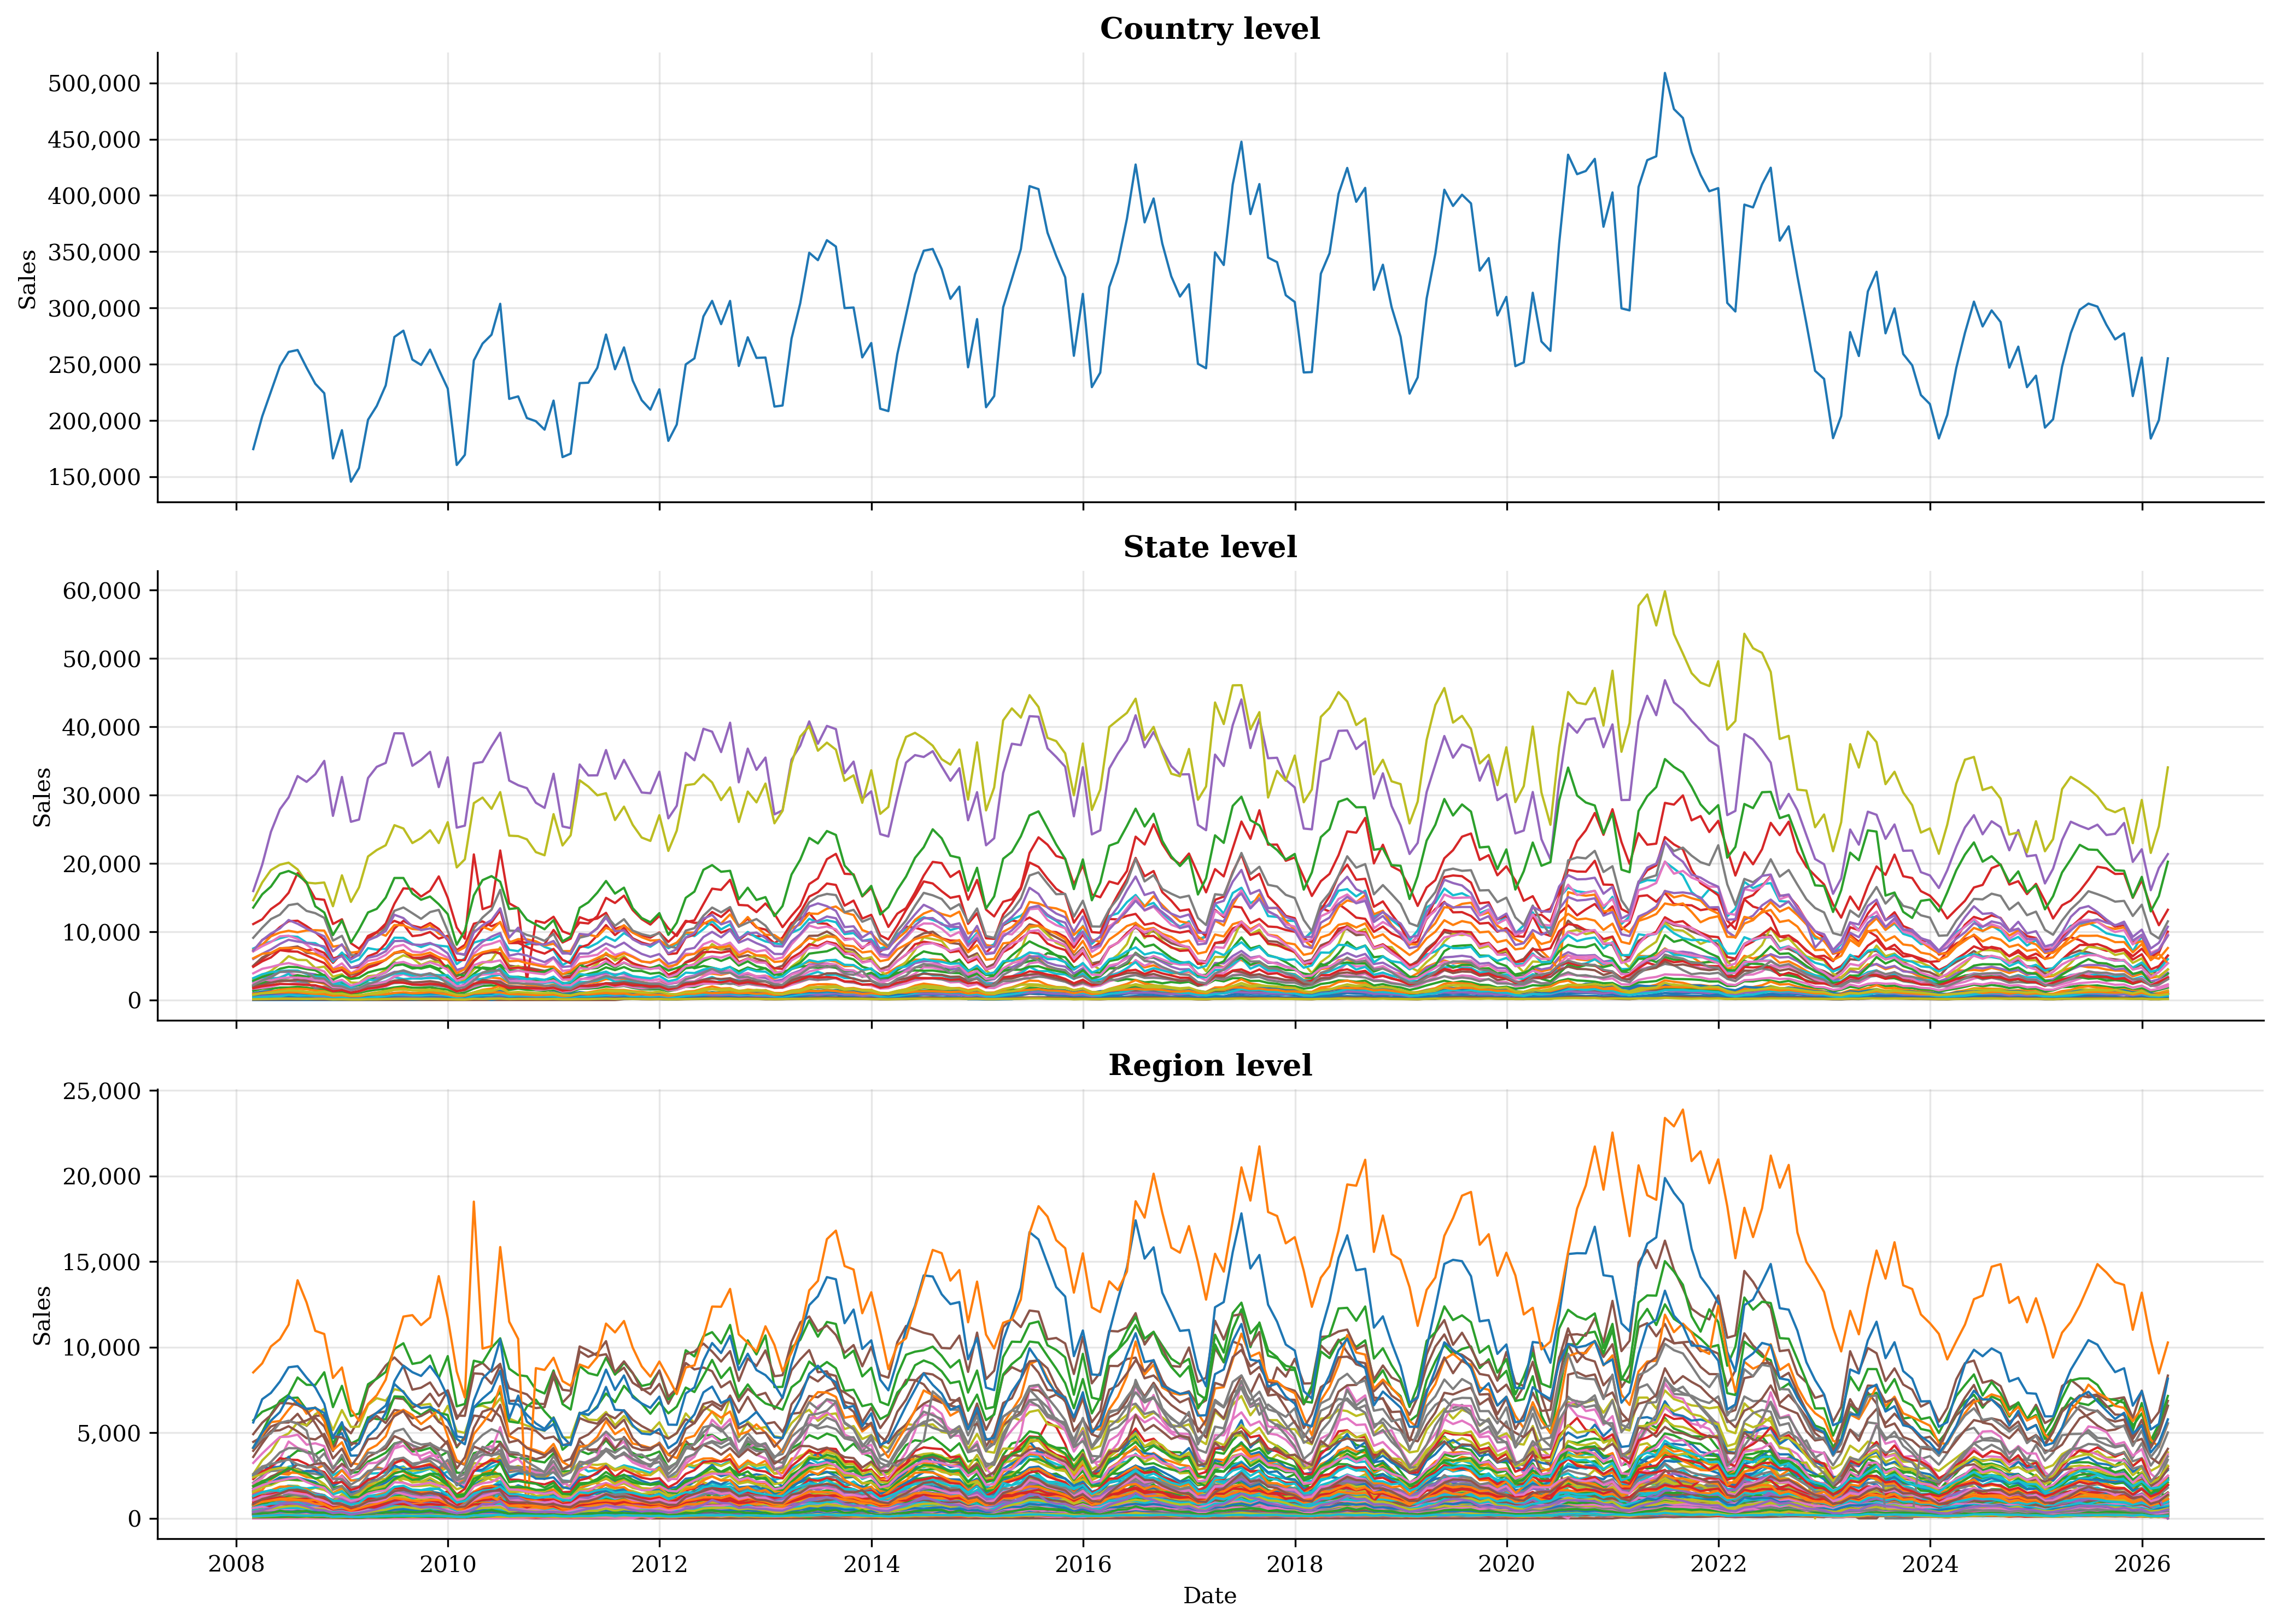

In [19]:
df = pd.read_csv("Data/zillow_houses_hierarchy_cleaned.csv", parse_dates=["ds"])
df["hierarchy_level"] = df["hierarchy_level"].astype(int)
df["y"] = pd.to_numeric(df["y"], errors="coerce")

level_names = {0: "Country level", 1: "State level", 2: "Region level"}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, level in zip(axes, [0, 1, 2]):
    data = df[df["hierarchy_level"] == level].sort_values(["unique_id", "ds"])

    for _, g in data.groupby("unique_id"):
        ax.plot(g["ds"], g["y"], linewidth=1)

    ax.set_title(level_names[level], fontsize=13, fontweight="bold")
    ax.set_ylabel("Sales")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [20]:
# How many time series exist per hierarchy level?
series_by_level = (df.groupby("hierarchy_level")["unique_id"].nunique().sort_index())

for level, n_series in series_by_level.items():
    print(f"{level_names[level]} level: {n_series:,} unique series")

Country level level: 1 unique series
State level level: 49 unique series
Region level level: 300 unique series


In [21]:
# Best and worst years at national level
df["year"] = df["ds"].dt.year
df["month"] = df["ds"].dt.month

us_yearly = (df[df["hierarchy_level"] == 0]
    .groupby("year", as_index=False)
    .agg(total_sales=("y", "sum")))

us_yearly["yoy_growth"] = us_yearly["total_sales"].pct_change() * 100
display(us_yearly.sort_values("total_sales", ascending=False).head(10))
display(us_yearly.sort_values("total_sales").head(10))

,year,total_sales,yoy_growth
13,2021,4992361.0,19.256217
12,2020,4186248.0,4.957796
9,2017,4137080.0,2.720259
14,2022,4044428.0,-18.987669
8,2016,4027521.0,5.000063
10,2018,4020953.0,-2.806980
11,2019,3988506.0,-0.806948
7,2015,3835732.0,9.501644
5,2013,3533411.0,13.721714
6,2014,3502899.0,-0.863528


,year,total_sales,yoy_growth
18,2026,639294.0,-79.607671
0,2008,2436429.0,NaN
2,2010,2682147.0,-2.161414
3,2011,2728438.0,1.725893
1,2009,2741400.0,12.517131
16,2024,3069301.0,-0.747731
15,2023,3092424.0,-23.538656
4,2012,3107068.0,13.877171
17,2025,3134973.0,2.139640
6,2014,3502899.0,-0.863528


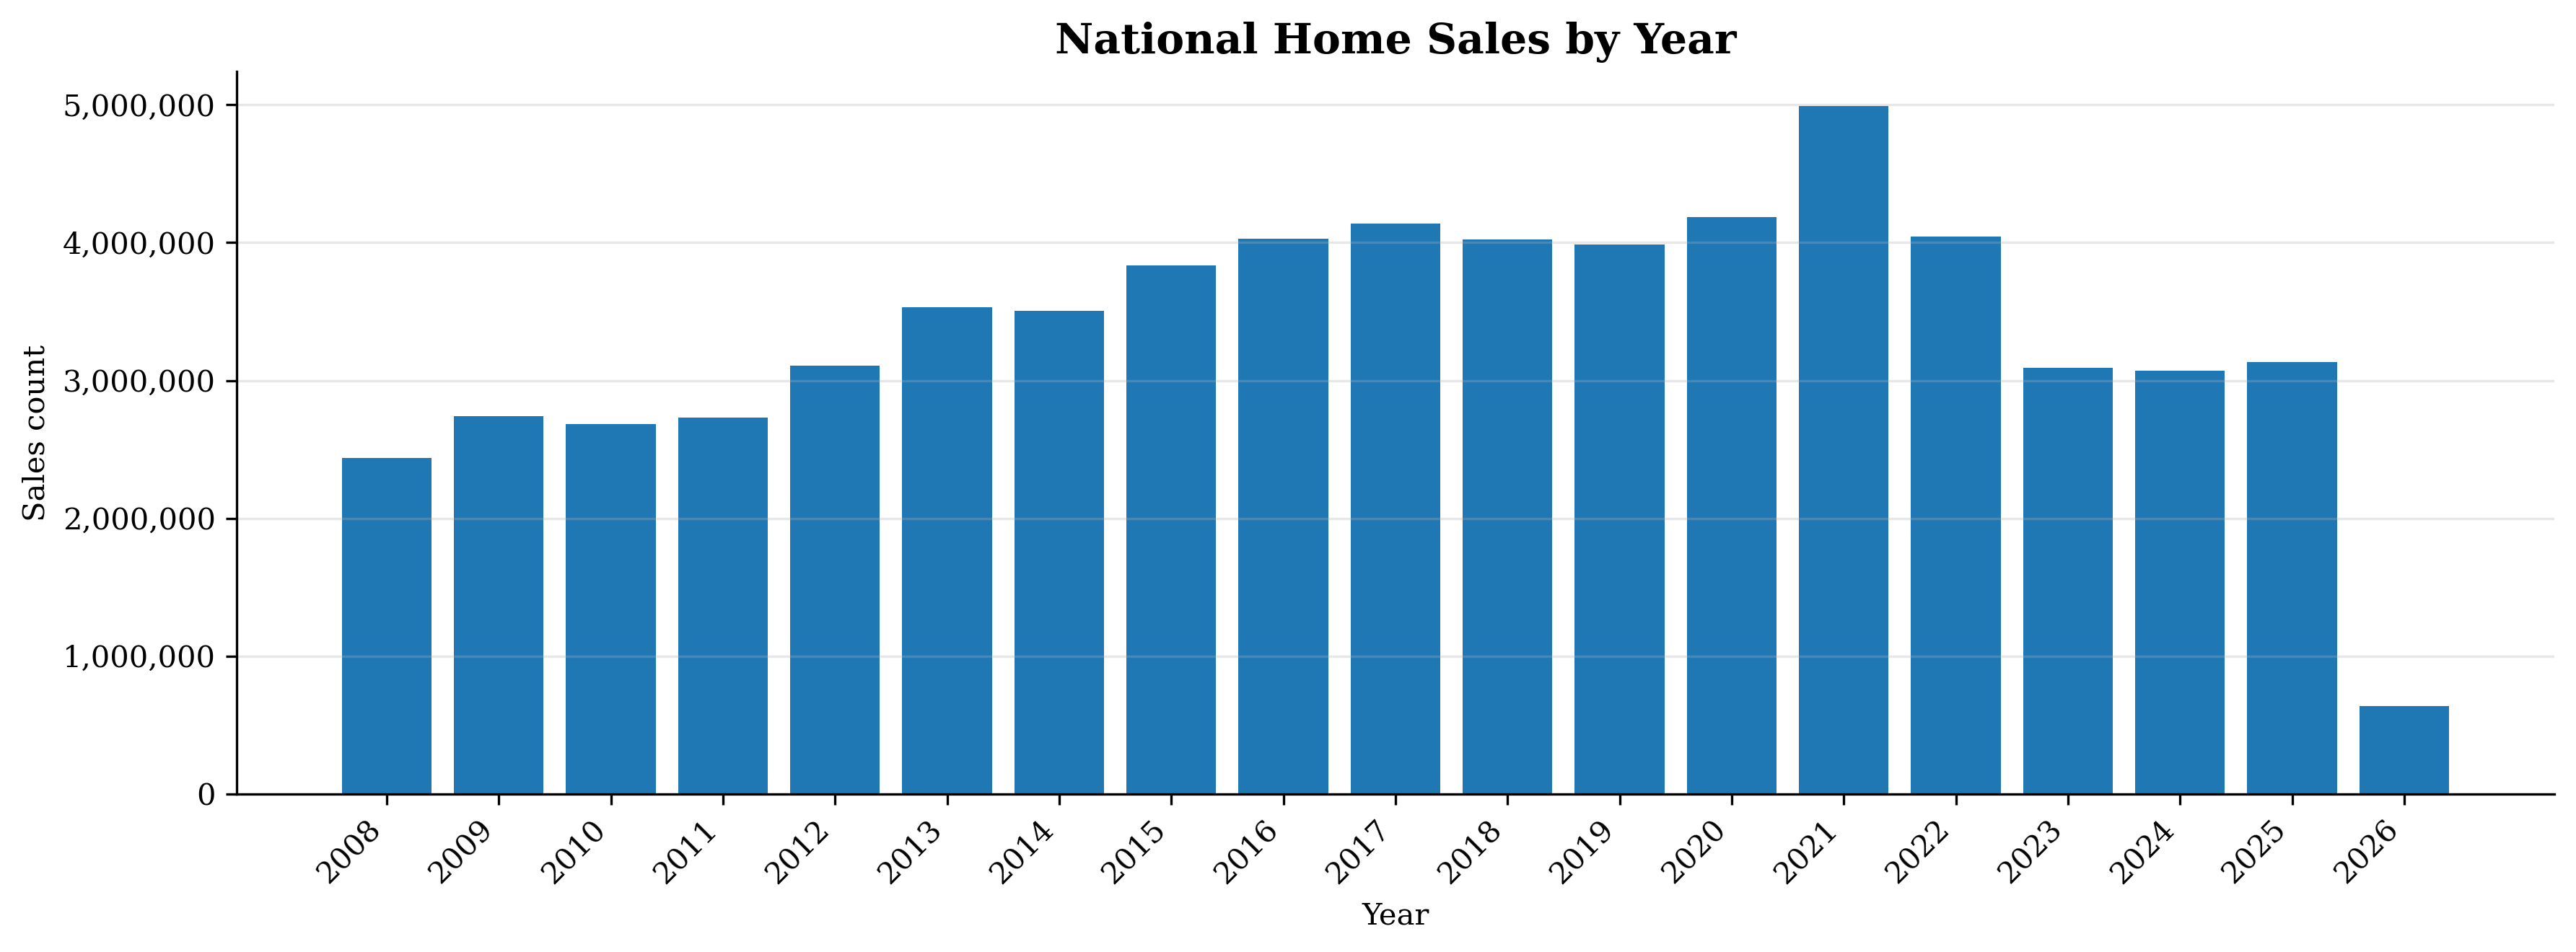

In [22]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.bar(us_yearly["year"], us_yearly["total_sales"])

ax.set_title("National Home Sales by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Sales count")

ax.set_xticks(us_yearly["year"])
ax.set_xticklabels(us_yearly["year"].astype(int), rotation=45, ha="right")

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
# States with the highest sales volume
state_sales = (df[df["hierarchy_level"] == 1]
    .groupby(["unique_id", "RegionName"], as_index=False)
    .agg(total_sales=("y", "sum"), avg_monthly_sales=("y", "mean"))
    .sort_values("total_sales", ascending=False))

display(state_sales.head(15))

,unique_id,RegionName,total_sales,avg_monthly_sales
8,US|FL,FL,7154682.0,32819.642202
4,US|CA,CA,6796895.0,31178.417431
42,US|TX,TX,4304431.0,19745.096330
33,US|NY,NY,3785702.0,17365.605505
37,US|PA,PA,2993301.0,13730.738532
13,US|IL,IL,2683346.0,12308.926606
44,US|VA,VA,2600527.0,11929.022936
9,US|GA,GA,2364542.0,10846.522936
21,US|MI,MI,2325217.0,10666.133028
26,US|NC,NC,2221074.0,10188.412844


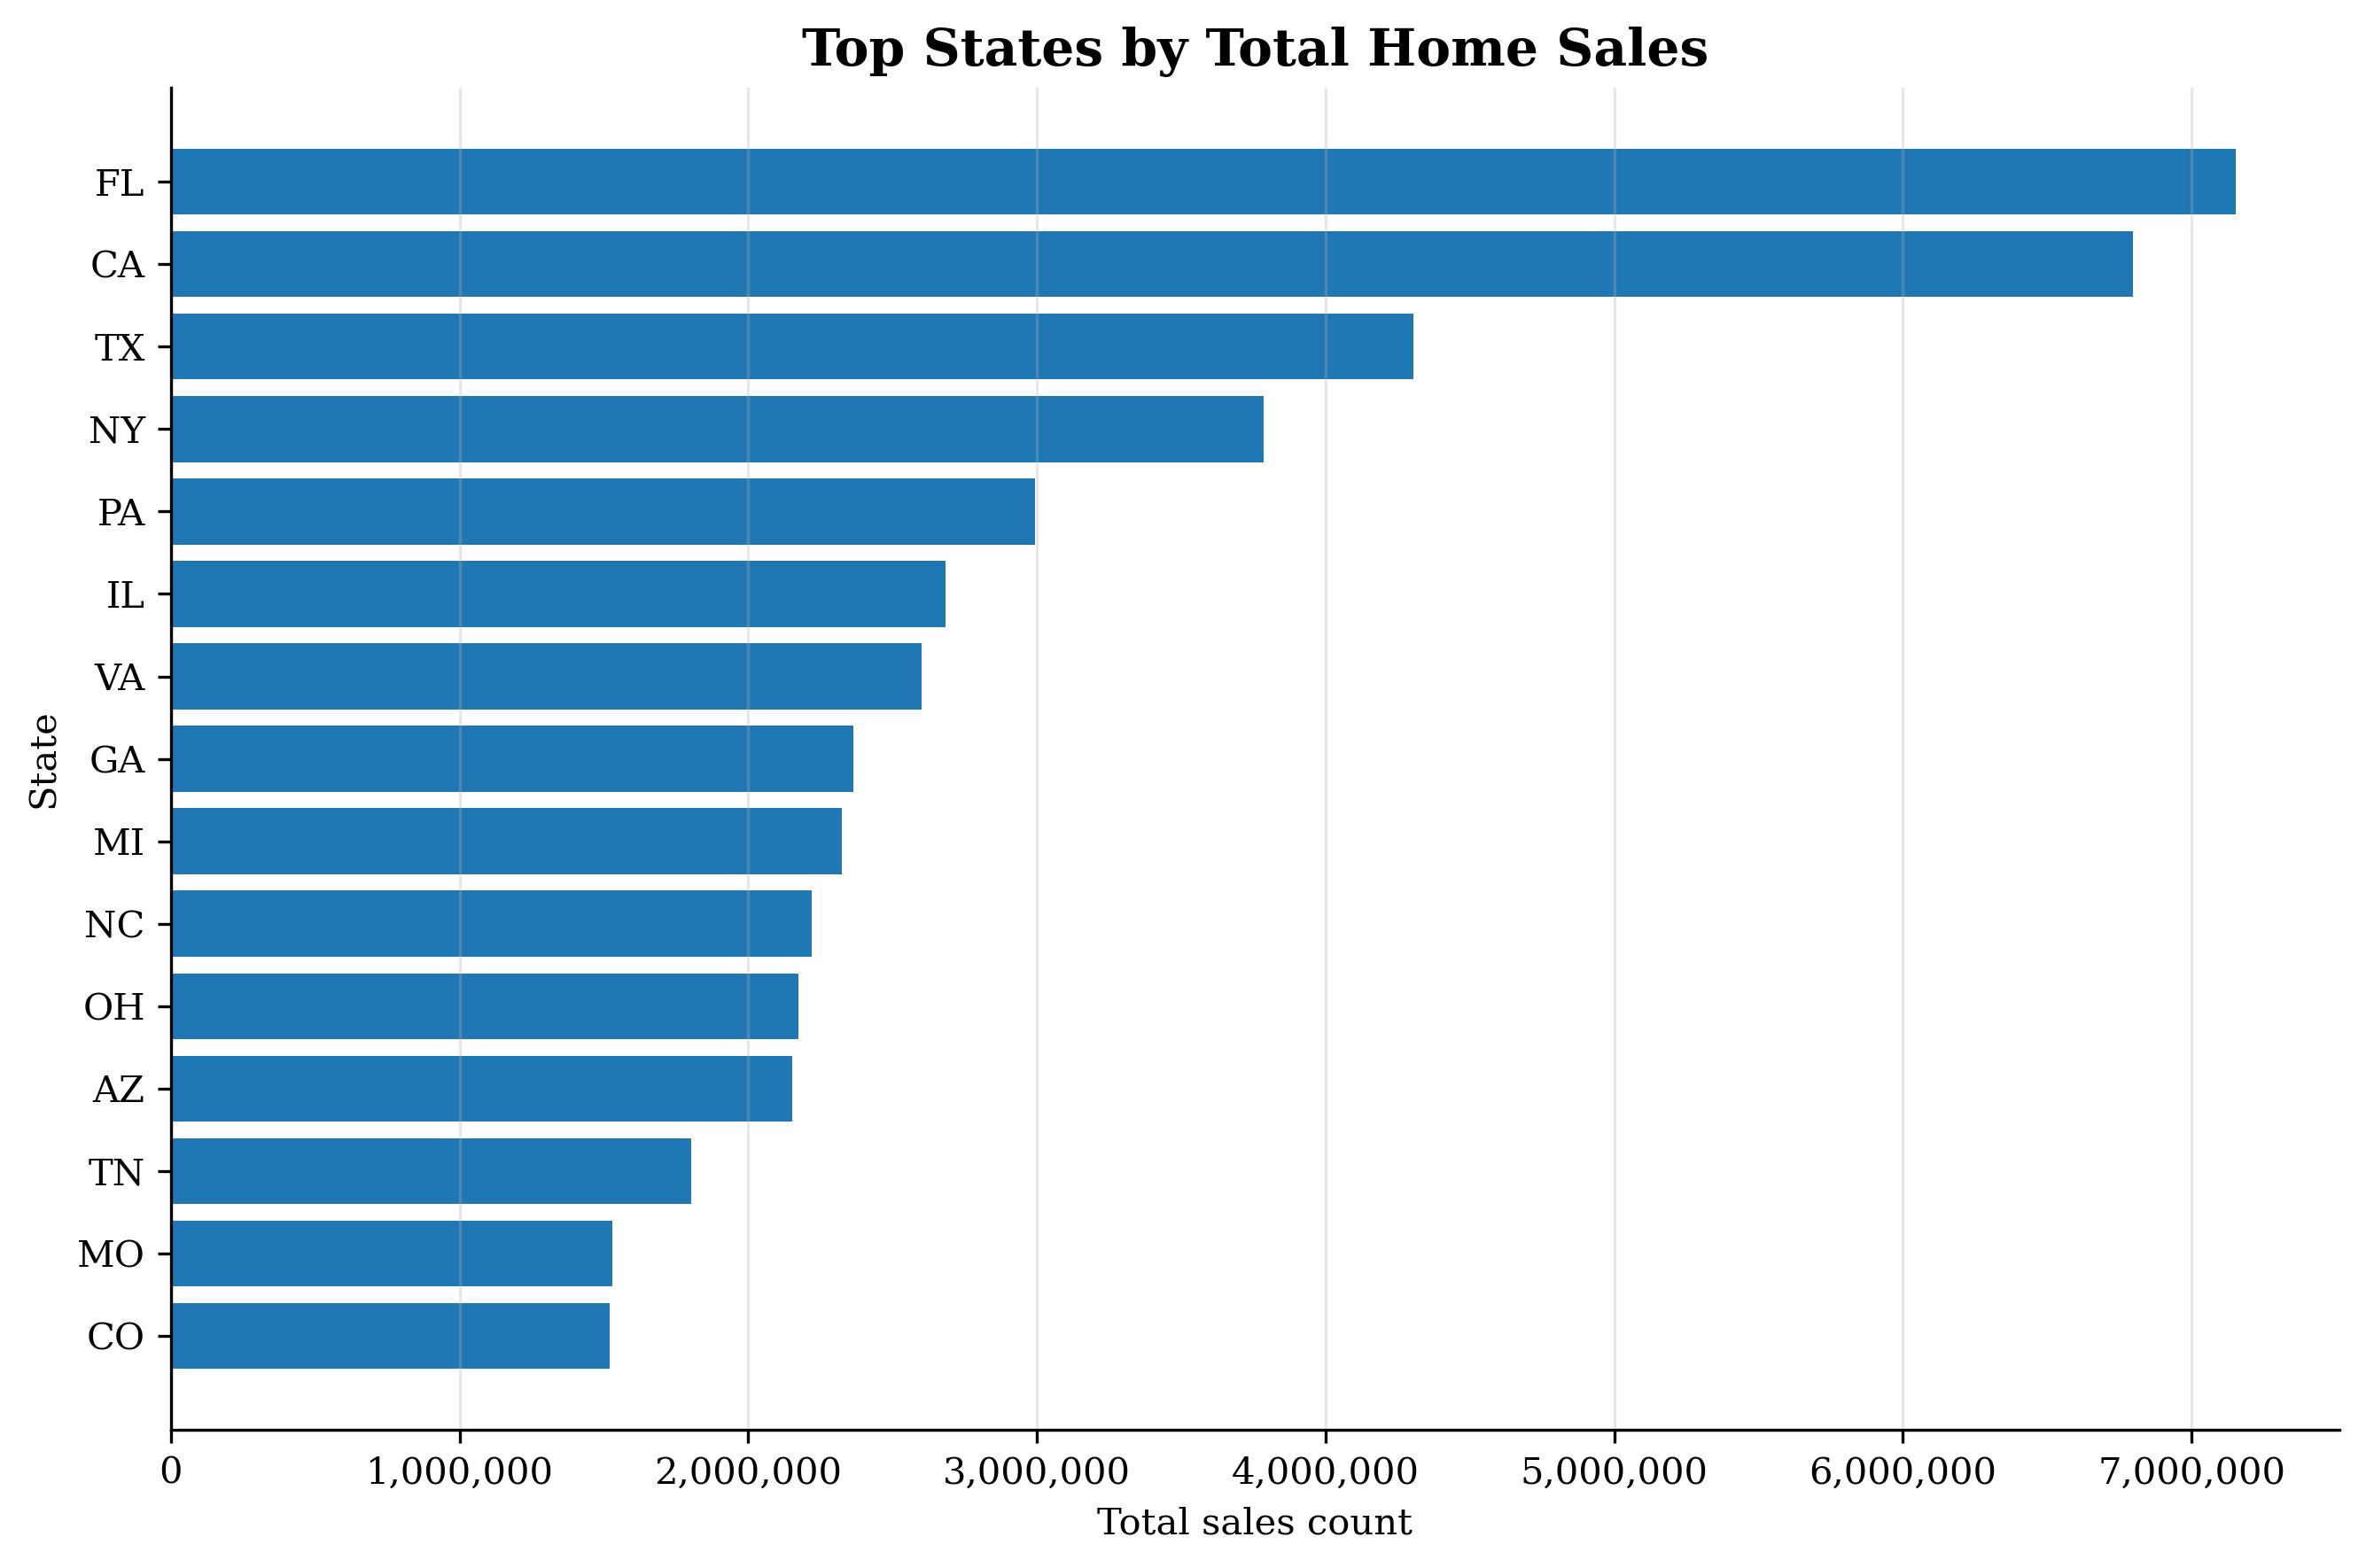

In [24]:
top_states = state_sales.head(15).sort_values("total_sales")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_states["RegionName"], top_states["total_sales"])
ax.set_title("Top States by Total Home Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total sales count")
ax.set_ylabel("State")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [25]:
# Regions with highest and lowest sales
region_sales = (
    df[df["hierarchy_level"] == 2]
    .groupby(["unique_id", "RegionName", "StateName"], as_index=False)
    .agg(
        total_sales=("y", "sum"),
        avg_monthly_sales=("y", "mean"),
        active_months=("y", lambda x: (x > 0).sum()),
        zero_month_share=("y", lambda x: (x == 0).mean())))

top_regions = region_sales.sort_values("total_sales", ascending=False).head(15)
bottom_regions = (region_sales[region_sales["active_months"] > 0]
    .sort_values(["total_sales", "active_months"], ascending=[True, False])
    .head(15))

display(top_regions)
display(bottom_regions)

,unique_id,RegionName,StateName,total_sales,avg_monthly_sales,active_months,zero_month_share
191,US|NY|394913,"New York, NY",NY,2957222.0,13565.238532,217,0.004587
100,US|IL|394463,"Chicago, IL",IL,2189481.0,10043.490826,218,0.000000
65,US|FL|394856,"Miami, FL",FL,1944096.0,8917.871560,218,0.000000
42,US|CA|753899,"Los Angeles, CA",CA,1826224.0,8377.174312,218,0.000000
82,US|GA|394347,"Atlanta, GA",GA,1786885.0,8196.720183,218,0.000000
15,US|AZ|394976,"Phoenix, AZ",AZ,1623086.0,7445.348624,218,0.000000
280,US|VA|395209,"Washington, DC",VA,1512765.0,6939.288991,218,0.000000
221,US|PA|394974,"Philadelphia, PA",PA,1427157.0,6546.591743,218,0.000000
255,US|TX|394514,"Dallas, TX",TX,1425284.0,6538.000000,218,0.000000
135,US|MI|394532,"Detroit, MI",MI,1284544.0,5892.403670,217,0.004587


,unique_id,RegionName,StateName,total_sales,avg_monthly_sales,active_months,zero_month_share
195,US|NY|845159,"Poughkeepsie, NY",NY,18936.0,86.862385,60,0.724771
161,US|NC|394635,"Goldsboro, NC",NC,23125.0,106.077982,218,0.000000
1,US|AL|394351,"Auburn, AL",AL,24250.0,111.238532,133,0.389908
181,US|NJ|395193,"Vineland, NJ",NJ,27045.0,124.059633,218,0.000000
264,US|TX|395094,"Sherman, TX",TX,27082.0,124.229358,218,0.000000
206,US|OK|394780,"Lawton, OK",OK,27560.0,126.422018,218,0.000000
202,US|OH|395117,"Springfield, OH",OH,29160.0,133.761468,218,0.000000
4,US|AL|394537,"Dothan, AL",AL,29169.0,133.802752,218,0.000000
16,US|AZ|395098,"Sierra Vista, AZ",AZ,29335.0,134.564220,218,0.000000
239,US|TN|394495,"Cookeville, TN",TN,30187.0,138.472477,218,0.000000


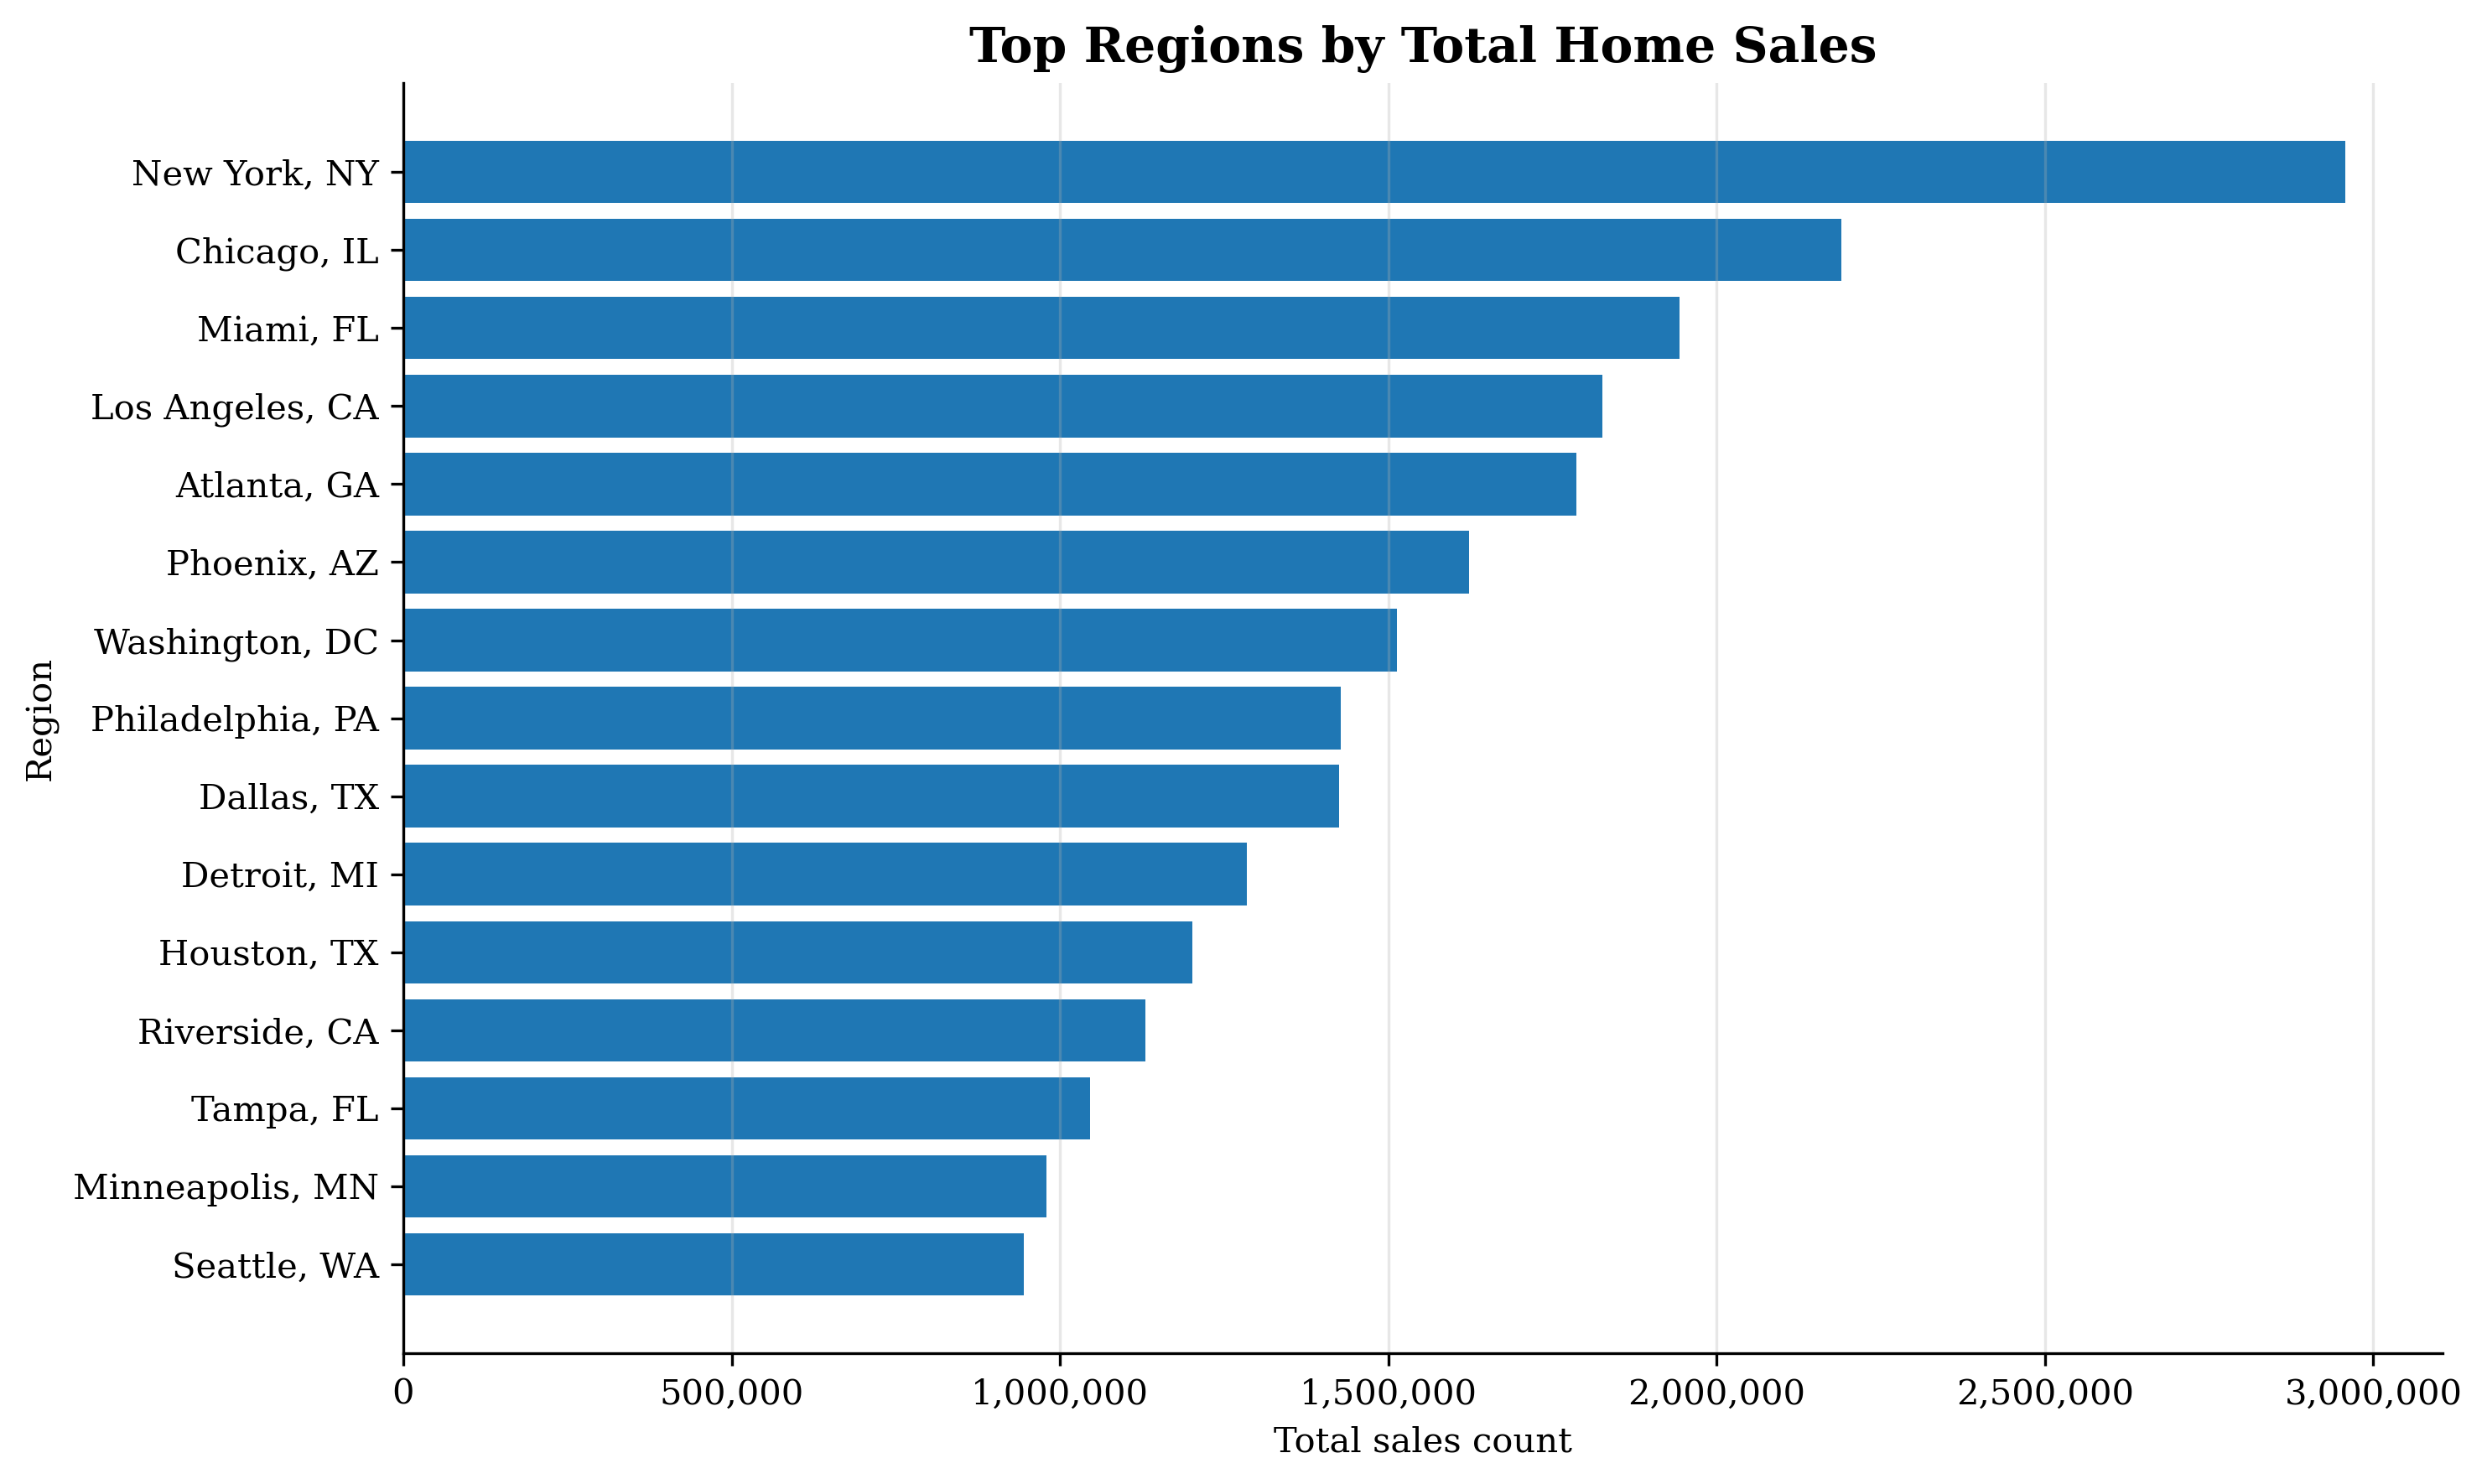

In [26]:
plot_df = top_regions.sort_values("total_sales")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(plot_df["RegionName"], plot_df["total_sales"])

ax.set_title("Top Regions by Total Home Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total sales count")
ax.set_ylabel("Region")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
# Trend analysis by region
region_yearly = (
    df[df["hierarchy_level"] == 2]
    .groupby(["unique_id", "RegionName", "StateName", "year"], as_index=False)
    .agg(yearly_sales=("y", "sum")))

def slope(x):
    if len(x) < 3:
        return np.nan
    t = np.arange(len(x))
    return np.polyfit(t, x, 1)[0]

region_trends = (
    region_yearly
    .sort_values(["unique_id", "year"])
    .groupby(["unique_id", "RegionName", "StateName"], as_index=False)
    .agg(
        total_sales=("yearly_sales", "sum"),
        avg_yearly_sales=("yearly_sales", "mean"),
        trend_slope=("yearly_sales", slope)))

display(region_trends.sort_values("trend_slope", ascending=False).head(15))
display(region_trends.sort_values("trend_slope").head(15))

,unique_id,RegionName,StateName,total_sales,avg_yearly_sales,trend_slope
191,US|NY|394913,"New York, NY",NY,2957222.0,155643.263158,1522.564912
158,US|NC|394458,"Charlotte, NC",NC,722845.0,38044.473684,773.512281
221,US|PA|394974,"Philadelphia, PA",PA,1427157.0,75113.526316,705.766667
77,US|FL|395148,"Tampa, FL",FL,1045718.0,55037.789474,641.478947
62,US|FL|394714,"Jacksonville, FL",FL,470753.0,24776.473684,618.903509
279,US|VA|395194,"Virginia Beach, VA",VA,458499.0,24131.526316,573.054386
257,US|TX|394692,"Houston, TX",TX,1201514.0,63237.578947,513.945614
233,US|SC|394898,"Myrtle Beach, SC",SC,288882.0,15204.315789,470.929825
82,US|GA|394347,"Atlanta, GA",GA,1786885.0,94046.578947,424.942105
130,US|MD|394358,"Baltimore, MD",MD,721705.0,37984.473684,401.540351


,unique_id,RegionName,StateName,total_sales,avg_yearly_sales,trend_slope
42,US|CA|753899,"Los Angeles, CA",CA,1826224.0,96117.052632,-2105.054386
28,US|CA|395025,"Riverside, CA",CA,1129949.0,59471.000000,-1734.349123
15,US|AZ|394976,"Phoenix, AZ",AZ,1623086.0,85425.578947,-1331.782456
32,US|CA|395057,"San Francisco, CA",CA,787016.0,41421.894737,-956.177193
185,US|NV|394775,"Las Vegas, NV",NV,778335.0,40965.000000,-945.536842
135,US|MI|394532,"Detroit, MI",MI,1284544.0,67607.578947,-828.100000
29,US|CA|395045,"Sacramento, CA",CA,580760.0,30566.315789,-748.264912
31,US|CA|395056,"San Diego, CA",CA,630942.0,33207.473684,-664.000000
46,US|CO|394530,"Denver, CO",CO,894874.0,47098.631579,-539.017544
13,US|AR|394798,"Little Rock, AR",AR,298330.0,15701.578947,-494.431579


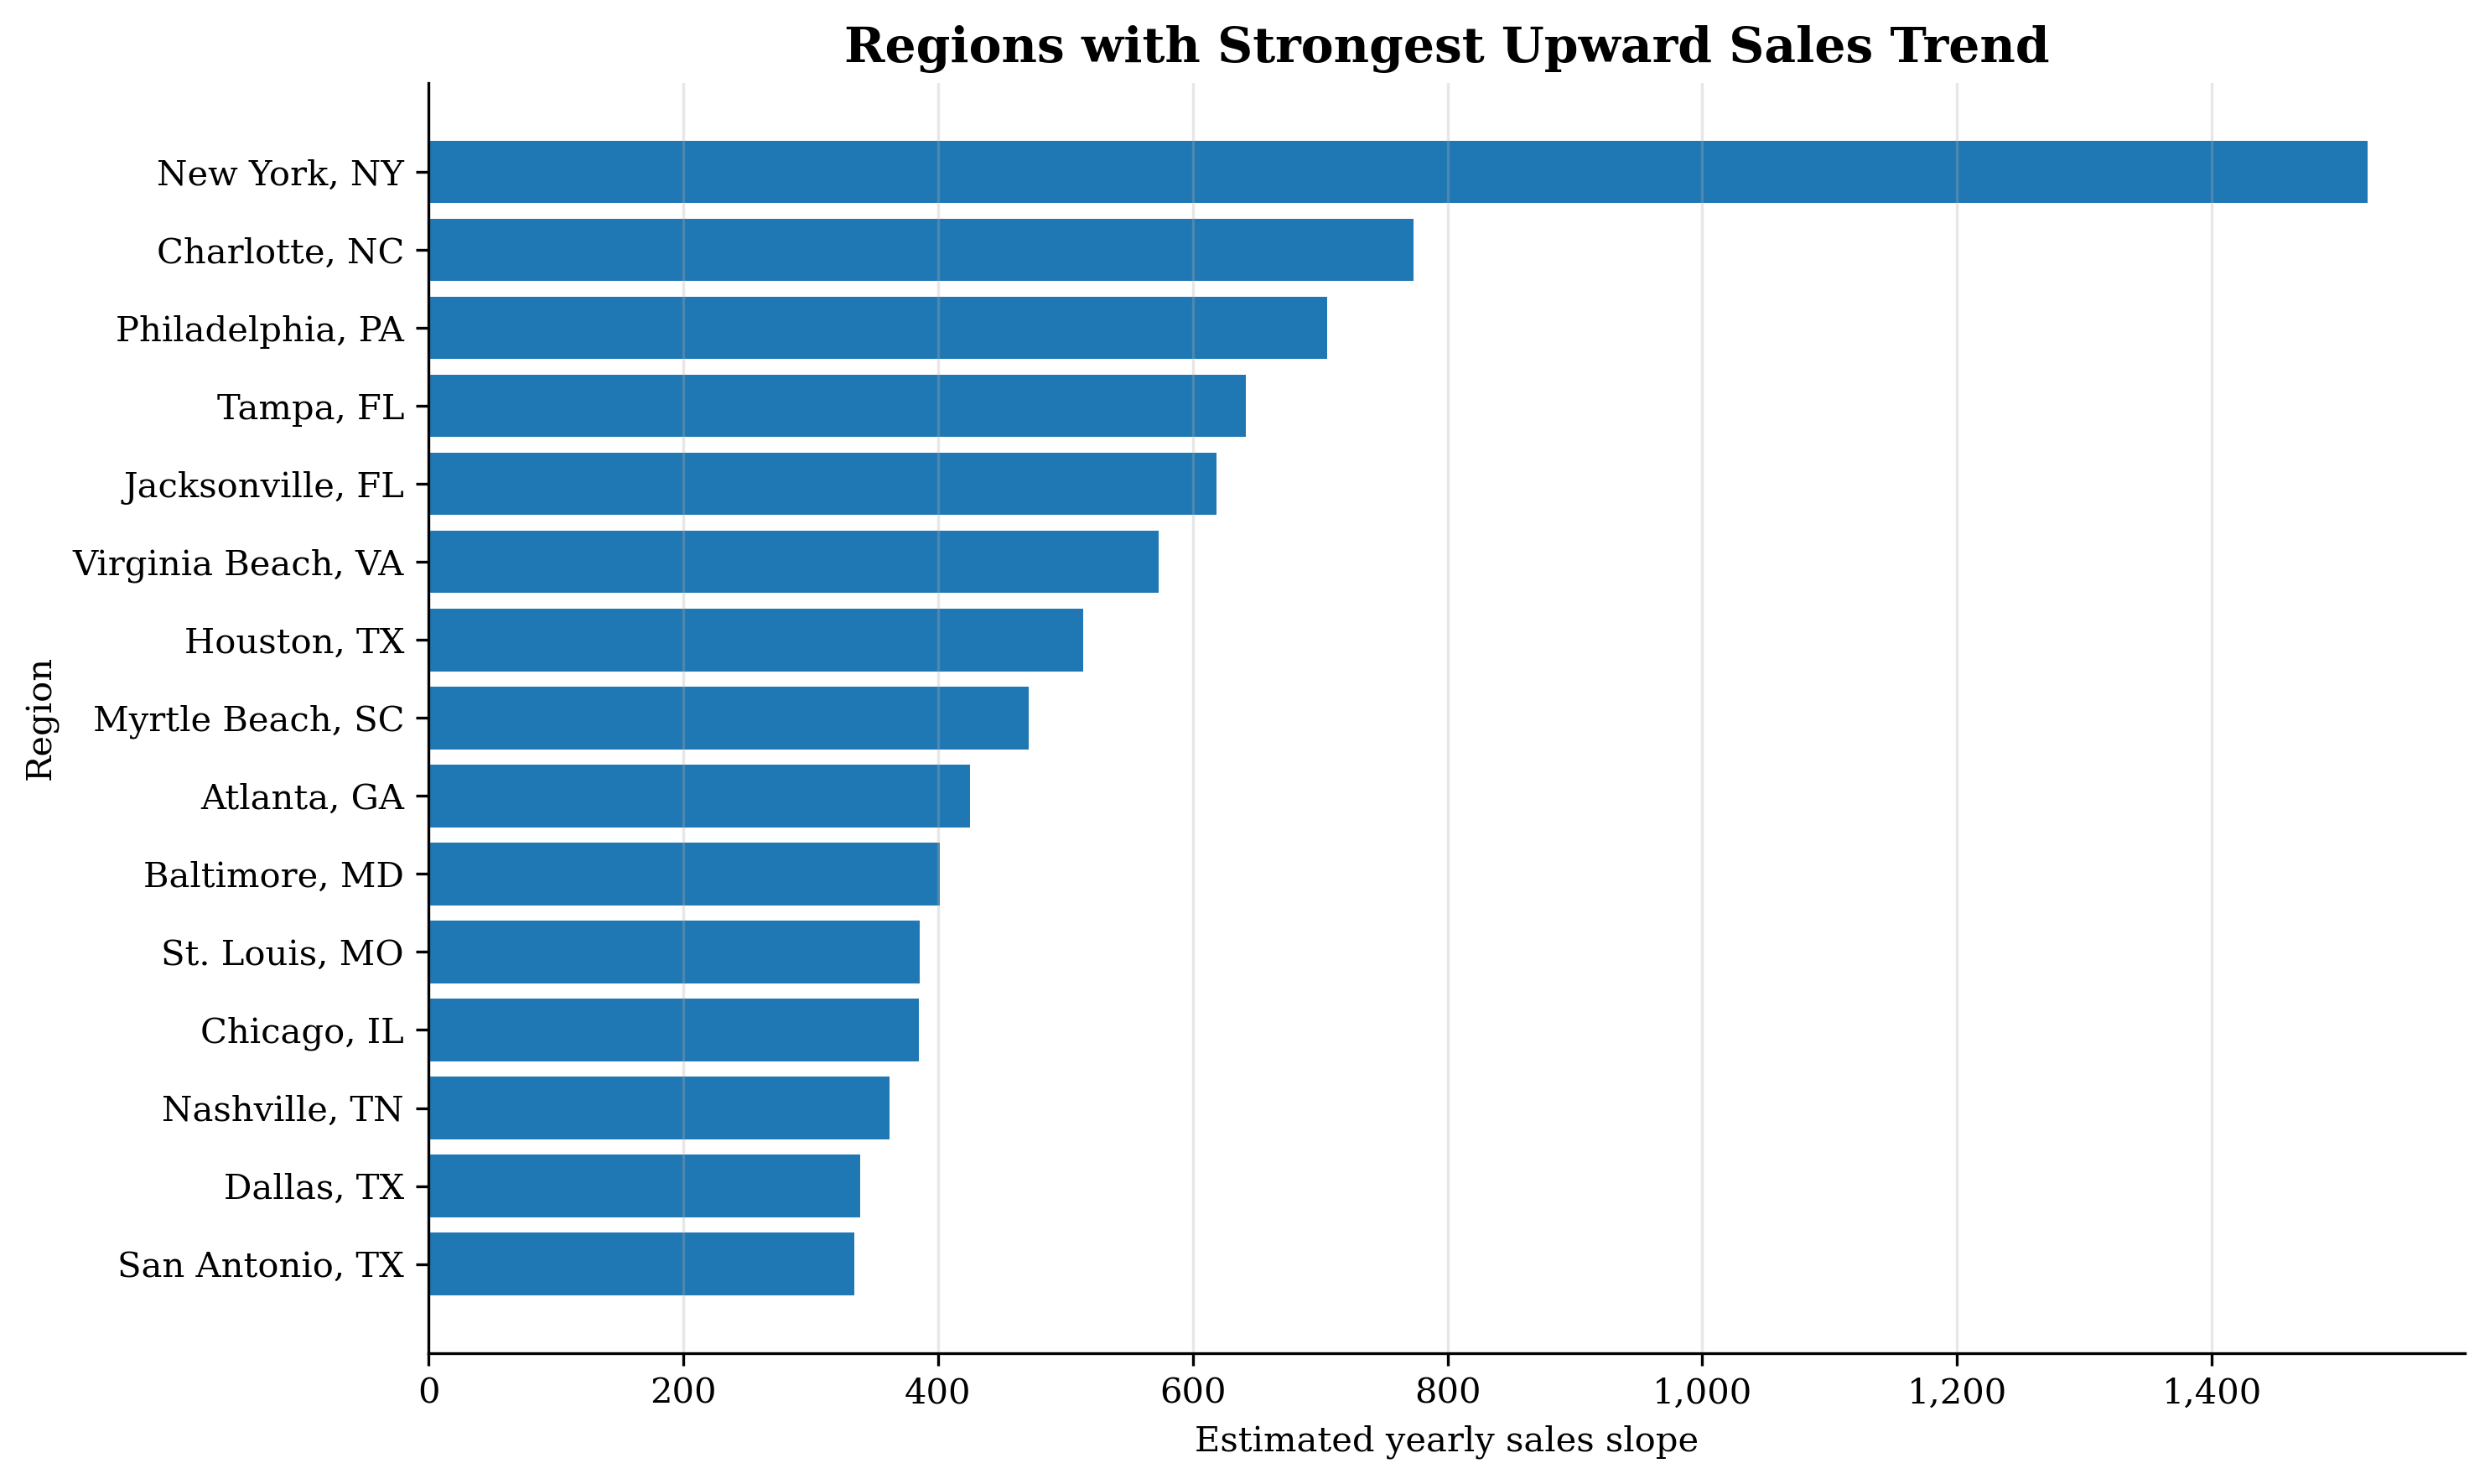

In [28]:
trend_plot = region_trends.sort_values("trend_slope", ascending=False).head(15)
trend_plot = trend_plot.sort_values("trend_slope")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(trend_plot["RegionName"], trend_plot["trend_slope"])

ax.set_title("Regions with Strongest Upward Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Estimated yearly sales slope")
ax.set_ylabel("Region")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

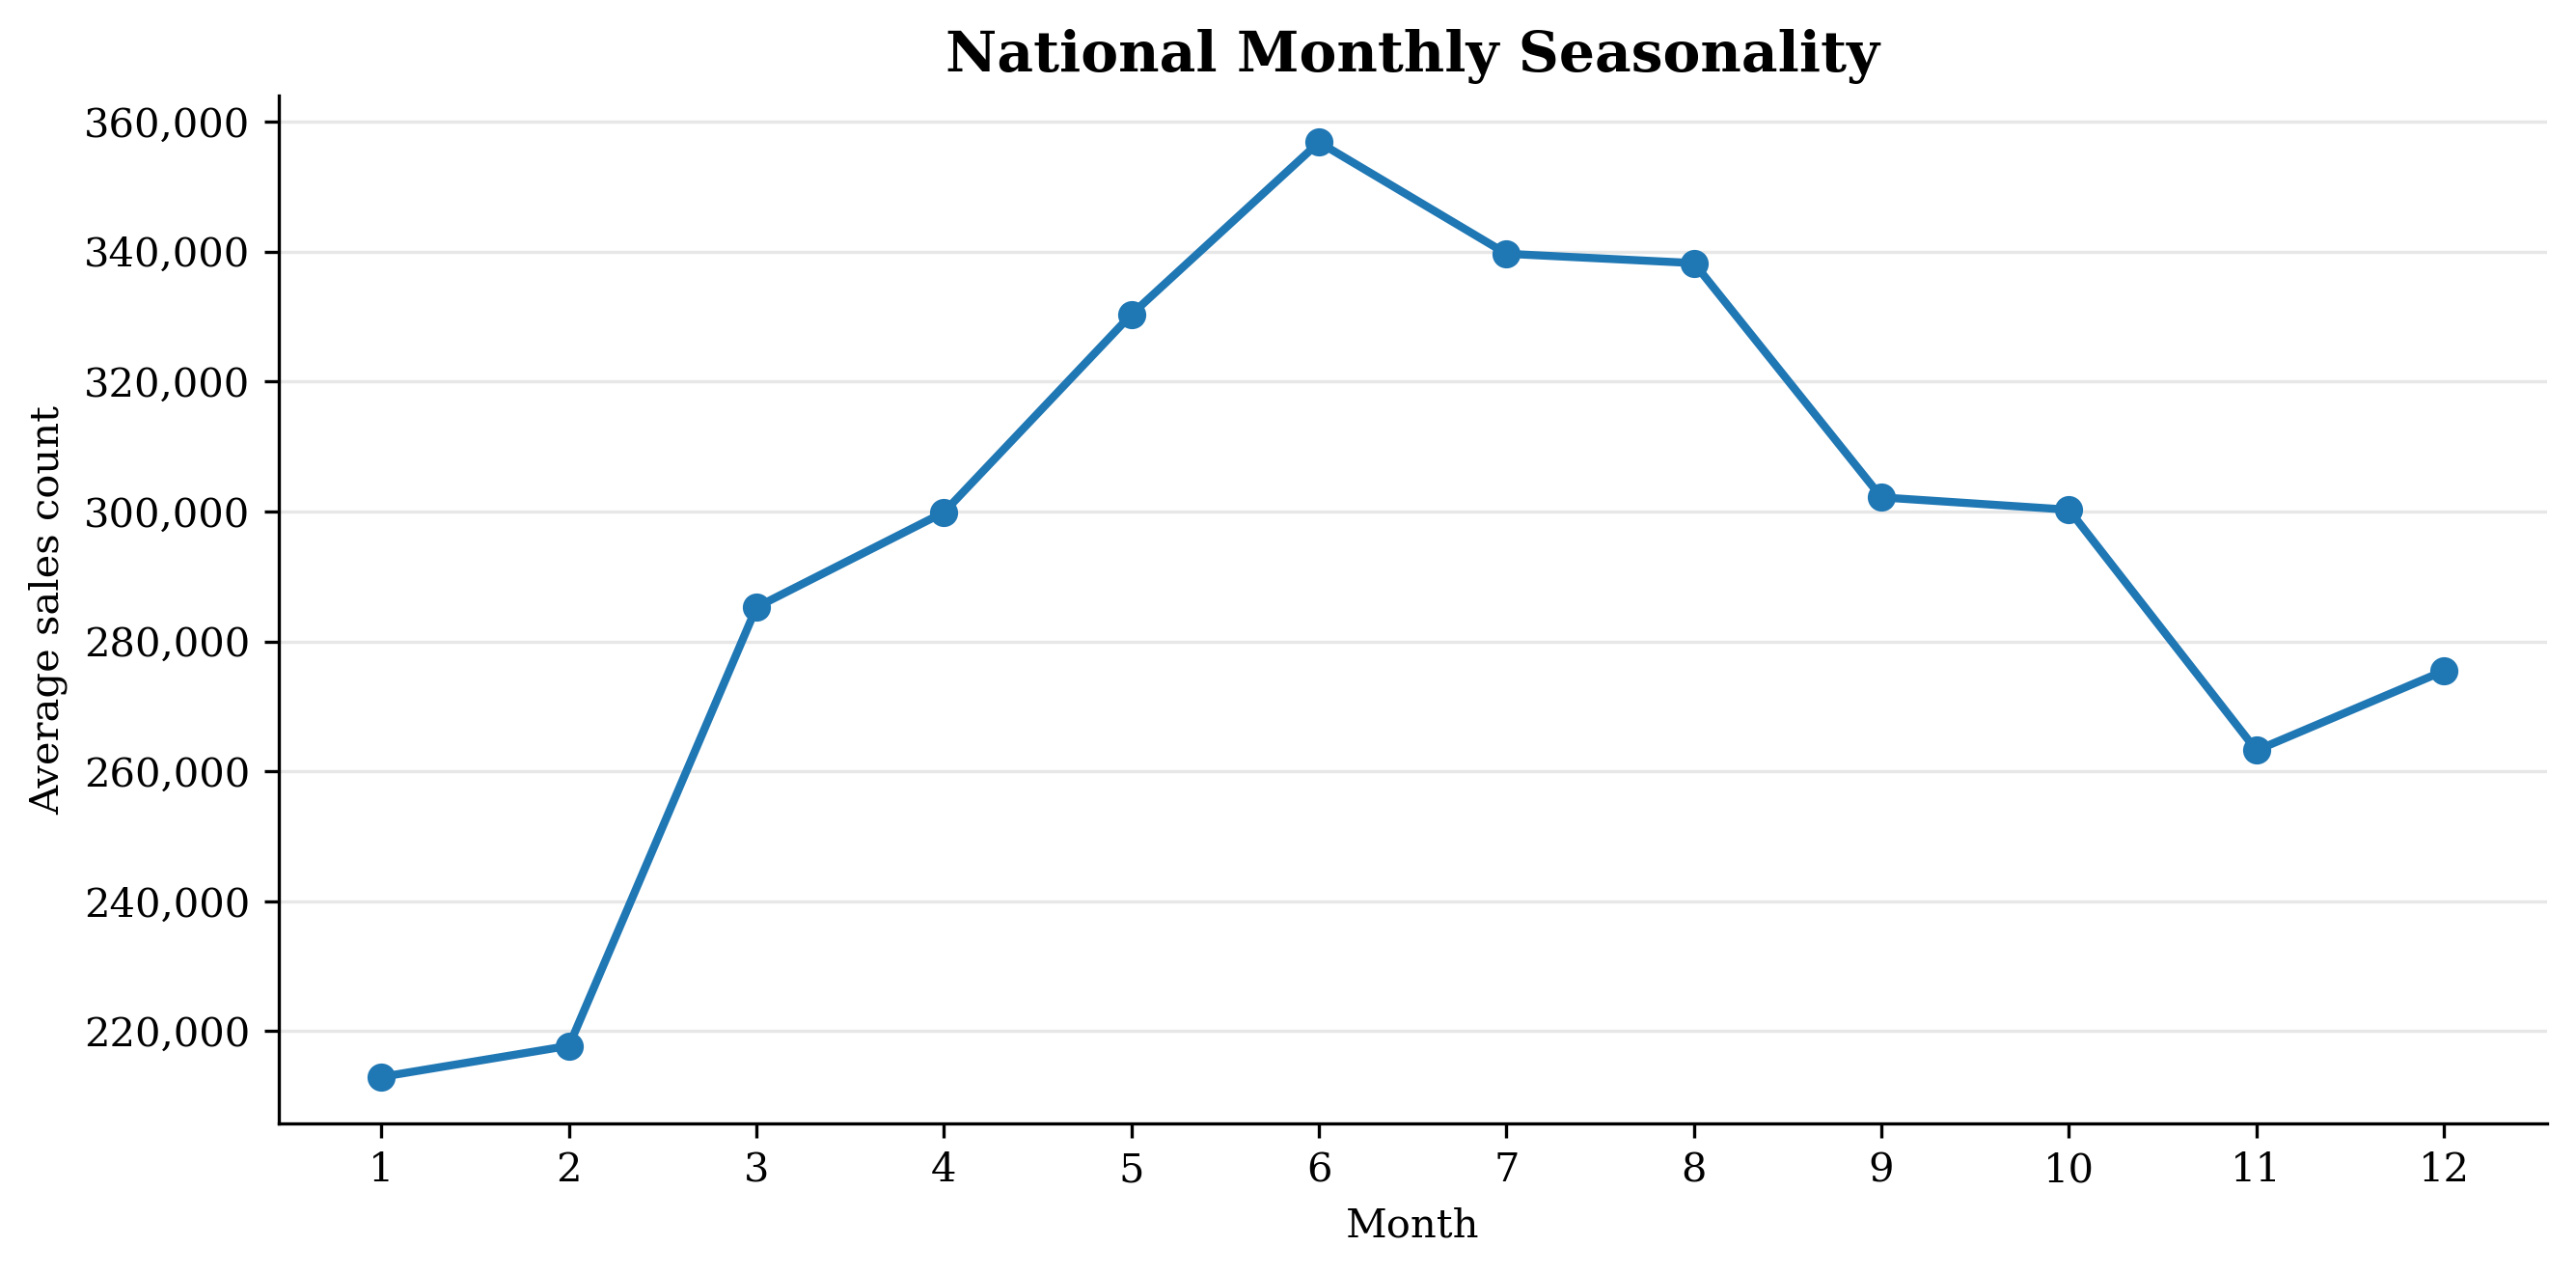

In [29]:
# Seasonality pattern
seasonality = (
    df[df["hierarchy_level"] == 0]
    .groupby("month", as_index=False)
    .agg(avg_sales=("y", "mean"))
)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(seasonality["month"], seasonality["avg_sales"], marker="o", linewidth=2)

ax.set_title("National Monthly Seasonality", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average sales count")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Concentration: how much do top regions contribute?
concentration = region_sales.sort_values("total_sales", ascending=False).copy()
concentration["sales_share"] = concentration["total_sales"] / concentration["total_sales"].sum()
concentration["cumulative_share"] = concentration["sales_share"].cumsum()
concentration["rank"] = np.arange(1, len(concentration) + 1)

display(concentration.head(20))

,unique_id,RegionName,StateName,total_sales,avg_monthly_sales,active_months,zero_month_share,sales_share,cumulative_share,rank
191,US|NY|394913,"New York, NY",NY,2957222.0,13565.238532,217,0.004587,0.046278,0.046278,1
100,US|IL|394463,"Chicago, IL",IL,2189481.0,10043.490826,218,0.000000,0.034264,0.080542,2
65,US|FL|394856,"Miami, FL",FL,1944096.0,8917.871560,218,0.000000,0.030424,0.110966,3
42,US|CA|753899,"Los Angeles, CA",CA,1826224.0,8377.174312,218,0.000000,0.028579,0.139545,4
82,US|GA|394347,"Atlanta, GA",GA,1786885.0,8196.720183,218,0.000000,0.027964,0.167509,5
15,US|AZ|394976,"Phoenix, AZ",AZ,1623086.0,7445.348624,218,0.000000,0.025400,0.192909,6
280,US|VA|395209,"Washington, DC",VA,1512765.0,6939.288991,218,0.000000,0.023674,0.216583,7
221,US|PA|394974,"Philadelphia, PA",PA,1427157.0,6546.591743,218,0.000000,0.022334,0.238917,8
255,US|TX|394514,"Dallas, TX",TX,1425284.0,6538.000000,218,0.000000,0.022305,0.261221,9
135,US|MI|394532,"Detroit, MI",MI,1284544.0,5892.403670,217,0.004587,0.020102,0.281323,10


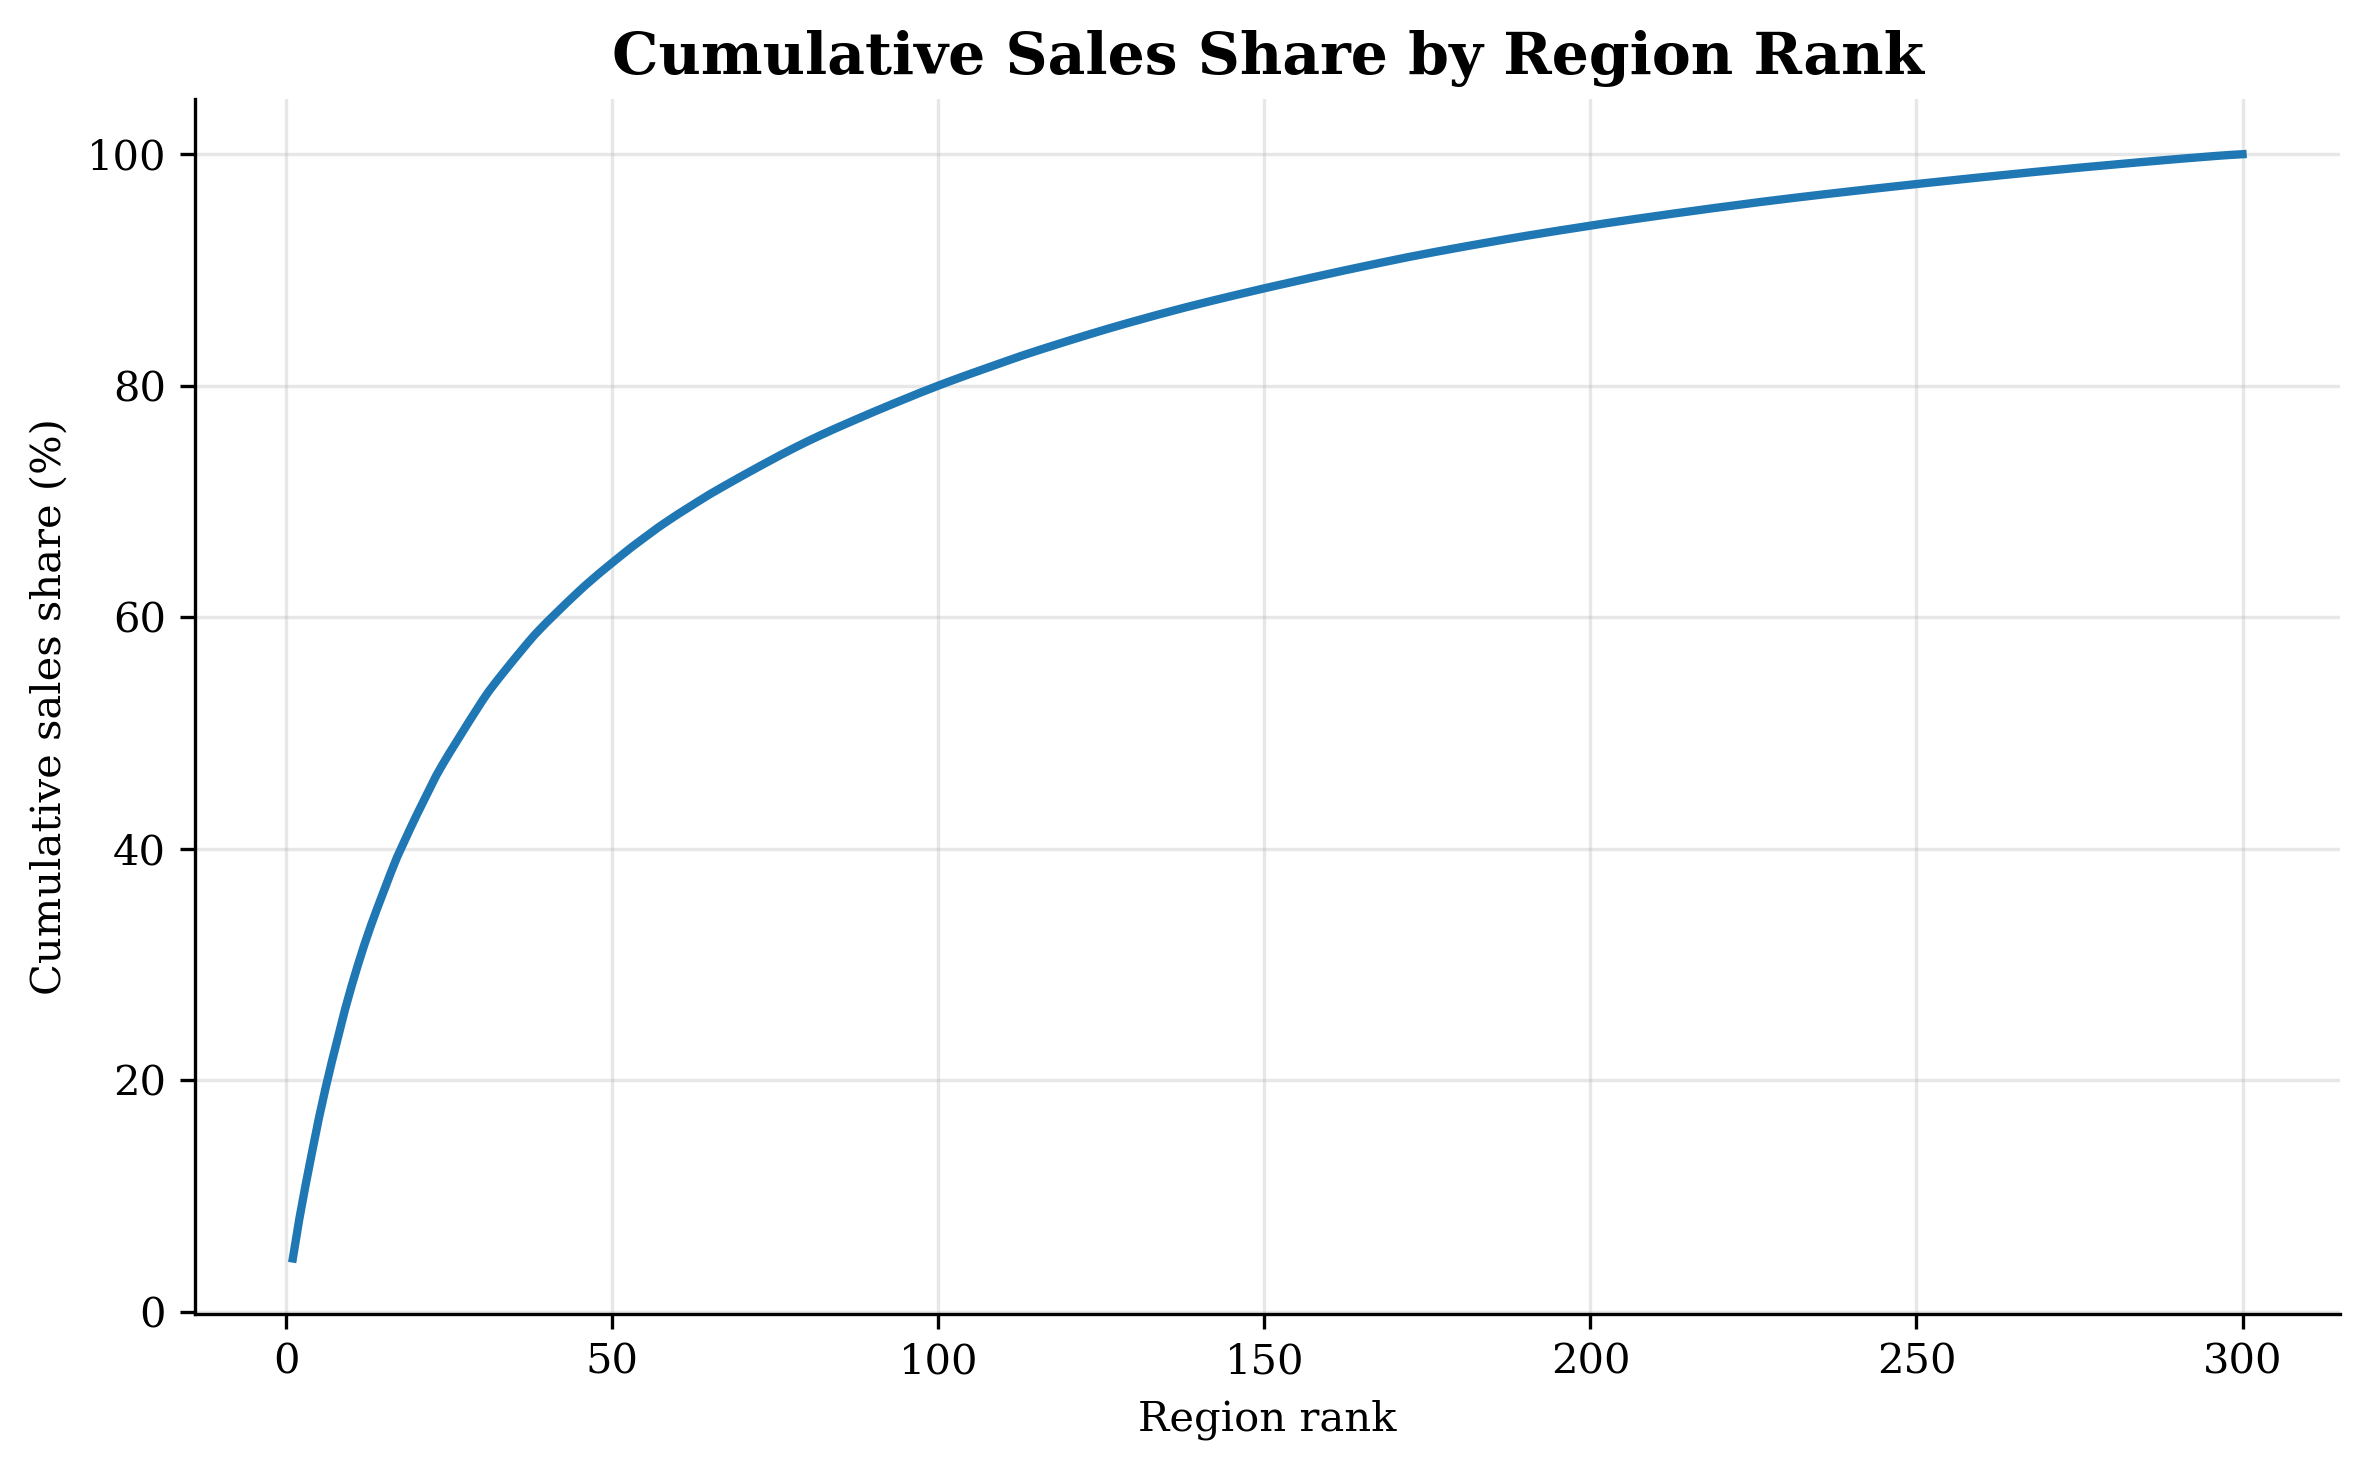

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(concentration["rank"], concentration["cumulative_share"] * 100, linewidth=2)

ax.set_title("Cumulative Sales Share by Region Rank", fontsize=14, fontweight="bold")
ax.set_xlabel("Region rank")
ax.set_ylabel("Cumulative sales share (%)")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()